=== DAY 43 — ROBUSTNESS TESTING (Random Seeds + Noise Injection) ===

 Final model loaded: quantum_alpha_final.pth

=== ROBUSTNESS TESTING RESULTS ===
    Seed  Noise Std    CAGR  Sharpe   MaxDD  Flat %
0     42       0.00 -0.0343 -1.6035 -0.1507    67.6
1     42       0.01 -0.0484 -1.8648 -0.1584    68.2
2     42       0.03 -0.0328 -1.5698 -0.1268    68.8
3    123       0.00 -0.0343 -1.6035 -0.1507    67.6
4    123       0.01 -0.0317 -1.5740 -0.1606    67.6
5    123       0.03 -0.0268 -1.2735 -0.1950    69.0
6    456       0.00 -0.0343 -1.6035 -0.1507    67.6
7    456       0.01 -0.0320 -1.6194 -0.1352    69.9
8    456       0.03 -0.0126 -1.2542 -0.1145    68.3
9    789       0.00 -0.0343 -1.6035 -0.1507    67.6
10   789       0.01 -0.0315 -1.5706 -0.1455    69.9
11   789       0.03 -0.0521 -1.8794 -0.1774    69.8
12  1011       0.00 -0.0343 -1.6035 -0.1507    67.6
13  1011       0.01 -0.0286 -1.5166 -0.1332    68.3
14  1011       0.03 -0.0351 -1.6325 -0.1238    67.9

=== ROBUSTNESS S

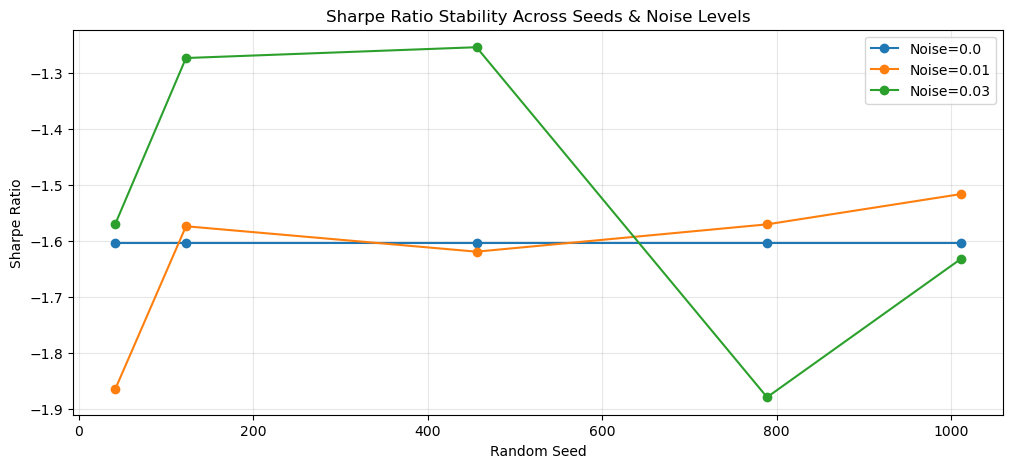

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=== DAY 43 — ROBUSTNESS TESTING (Random Seeds + Noise Injection) ===\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================
# 1. FINAL DQN MODEL
# =============================================
class DQN(nn.Module):
    def __init__(self, state_size=7, action_size=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, action_size)
        )
    def forward(self, x):
        return self.net(x)

policy_net = DQN().to(device)
policy_net.load_state_dict(torch.load("../models/quantum_alpha_final.pth", map_location=device))
policy_net.eval()
print(" Final model loaded: quantum_alpha_final.pth")

# =============================================
# 2. ENVIRONMENT (with optional noise)
# =============================================
class QuantumAlphaEnv:
    def __init__(self, data, noise_std=0.0):
        self.data = data.reset_index(drop=True)
        self.feature_cols = ["mom_20_norm", "vol_signal_norm", "trend_signal_norm",
                             "dd_signal_norm", "vix_signal_norm", "breadth_signal_norm"]
        self.noise_std = noise_std
        self.max_steps = len(self.data) - 1
        self.reset()
   
    def reset(self):
        self.current_step = 0
        self.position = 0
        self.balance = 1.0
        return self._get_observation()
   
    def _get_observation(self):
        row = self.data.iloc[self.current_step]
        obs = row[self.feature_cols].values.astype(np.float32)
        if self.noise_std > 0:
            noise = np.random.normal(0, self.noise_std, obs.shape)
            obs = obs + noise
        return np.append(obs, self.position)
   
    def step(self, action):
        prev_position = self.position
        new_position = {0: 0, 1: 1, 2: -1}[action]
        ret = self.data.iloc[self.current_step]["nifty_ret"]
        cost = abs(new_position - prev_position) * 0.0005
        net_ret = prev_position * ret - cost
        self.balance *= (1 + net_ret)
        self.position = new_position
        self.current_step += 1
        done = self.current_step >= self.max_steps
        return self._get_observation(), net_ret, done, {"net_ret": net_ret, "position": self.position}

# =============================================
# 3. ROBUSTNESS TEST FUNCTION
# =============================================
def run_robustness_test(test_data, noise_std=0.0, seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    env = QuantumAlphaEnv(test_data, noise_std=noise_std)
    state = env.reset()
    done = False
    equity = 1.0
    equity_curve = [1.0]
    positions = []
    
    while not done:
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(device)
            action = policy_net(s).argmax().item()
        next_state, _, done, info = env.step(action)
        equity *= (1 + info["net_ret"])
        equity_curve.append(equity)
        positions.append(info["position"])
        state = next_state
    
    equity_arr = np.array(equity_curve)
    returns = np.diff(equity_arr) / equity_arr[:-1]
    
    cagr = equity_arr[-1] ** (252 / len(returns)) - 1
    sharpe = (np.mean(returns) - 0.065/252) / (np.std(returns) + 1e-8) * np.sqrt(252)
    max_dd = (equity_arr / np.maximum.accumulate(equity_arr) - 1).min()
    
    return {
        "CAGR": round(cagr, 4),
        "Sharpe": round(sharpe, 4),
        "MaxDD": round(max_dd, 4),
        "Flat %": round((np.array(positions) == 0).mean() * 100, 1)
    }

# =============================================
# 4. MULTIPLE RANDOM SEEDS + NOISE LEVELS
# =============================================
test_data = pd.read_csv("../data/state_dataset.csv", index_col="Date", parse_dates=True)
test_data = test_data.join(pd.read_csv("../data/market_master.csv", index_col="Date", parse_dates=True)[["nifty_ret"]])
test_data = test_data.loc["2023":"2025"]

seeds = [42, 123, 456, 789, 1011]
noise_levels = [0.0, 0.01, 0.03]

robust_results = []
for seed in seeds:
    for noise in noise_levels:
        result = run_robustness_test(test_data, noise_std=noise, seed=seed)
        robust_results.append({
            "Seed": seed,
            "Noise Std": noise,
            **result
        })

robust_df = pd.DataFrame(robust_results)
print("\n=== ROBUSTNESS TESTING RESULTS ===")
print(robust_df.round(4))

# Summary statistics
print("\n=== ROBUSTNESS SUMMARY ===")
print(f"Average Sharpe: {robust_df['Sharpe'].mean():.4f}")
print(f"Sharpe Std Dev: {robust_df['Sharpe'].std():.4f}")
print(f"Average MaxDD:  {robust_df['MaxDD'].mean():.4f}")

# =============================================
# 5. VISUALISATION
# =============================================
plt.figure(figsize=(12, 5))
for noise in noise_levels:
    subset = robust_df[robust_df["Noise Std"] == noise]
    plt.plot(subset["Seed"], subset["Sharpe"], marker='o', label=f"Noise={noise}")
plt.title("Sharpe Ratio Stability Across Seeds & Noise Levels")
plt.xlabel("Random Seed")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()